<a href="https://colab.research.google.com/github/MisbahKhan0009/299test/blob/main/Copy_of_CSE299_Week_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
!git clone https://github.com/NusratNiha1/CSE299.git

fatal: destination path 'CSE299' already exists and is not an empty directory.


# Section 1: Install and Import Dependencies

In [14]:
# Section 1: Install and Import Dependencies

import os
import sys
import json
import random
from pathlib import Path
from typing import List, Tuple
from tqdm import tqdm
import numpy as np
import pandas as pd
import librosa
import librosa.display
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    f1_score,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

print('torch', torch.__version__)

torch 2.8.0+cu126


# Section 2: Configure Paths and Hyperparameters

In [15]:
# Section 2: Configure Paths and Hyperparameters
from pathlib import Path
import torch

#root directory
repo_root = Path("/content/CSE299")


# Dataset paths
dataset_root = repo_root / "Dataset" / "balanced"
cry_dir = dataset_root / "cry"
noncry_dir = dataset_root / "non-cry_standardized"

# Output directories
output_dir = repo_root / "models"
fig_dir = repo_root / "notebooks" / "figures"

# Ensure directories exist
output_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)

# Audio/feature configuration
SAMPLE_RATE = 16000
DURATION_SECONDS = 5
N_SAMPLES = SAMPLE_RATE * DURATION_SECONDS
N_MELS = 64
FFT = 1024
HOP = 256
TARGET_DB = -20.0

# Training configuration
BATCH_SIZE = 32
EPOCHS = 200
LEARNING_RATE = 1e-3
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15
SEED = 42

# Device configuration
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Print summary
print(f"Device: {DEVICE}")
print(f"Dataset root: {dataset_root}")
print(f"Cry dir exists? {cry_dir.exists()}")
print(f"Non-cry dir exists? {noncry_dir.exists()}")
print(f"Figures directory: {fig_dir}")
print(f"Output directory: {output_dir}")


Device: cuda
Dataset root: /content/CSE299/Dataset/balanced
Cry dir exists? True
Non-cry dir exists? True
Figures directory: /content/CSE299/notebooks/figures
Output directory: /content/CSE299/models


### 📁 **Directory Setup**

```python
repo_root = Path("/content/CSE299")
dataset_root = repo_root / "Dataset" / "balanced"
cry_dir = dataset_root / "cry"
noncry_dir = dataset_root / "non-cry_standardized"
```

These define where your **cry** and **non-cry** datasets are stored.
It assumes a structure like:

```
/content/CSE299/
    ├── Dataset/
    │   └── balanced/
    │       ├── cry/
    │       └── non-cry_standardized/
```

---

### 📤 **Output Directories**

```python
output_dir = repo_root / "models"
fig_dir = repo_root / "notebooks" / "figures"

output_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)
```

These ensure folders exist to **save trained models** (`models/`) and **graphs/plots** (`notebooks/figures/`).

---

### 🎧 **Audio & Feature Configuration**

```python
SAMPLE_RATE = 16000        # Hz, standard for speech/audio
DURATION_SECONDS = 5
N_SAMPLES = SAMPLE_RATE * DURATION_SECONDS
N_MELS = 64                 # Mel filterbanks (features)
FFT = 1024                  # Fast Fourier Transform window
HOP = 256                   # Hop length for STFT
TARGET_DB = -20.0           # Normalization target
```

These parameters will be used by **librosa** or your custom preprocessing function to extract **Mel-spectrograms** or **MFCCs**.

---

### ⚙️ **Training Configuration**

```python
BATCH_SIZE = 32
EPOCHS = 2
LEARNING_RATE = 1e-3
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15
SEED = 42
```

Defines **batch size**, **learning rate**, **splits for validation/test**, and **random seed** for reproducibility.
(EPOCHS = 2 is fine for testing; increase later for final training.)

---

### 🧠 **Device Selection**

```python
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
```

Automatically uses GPU if available — otherwise defaults to CPU.

---

### 🖨️ **Summary Print**

```python
print(f"Device: {DEVICE}")
print(f"Dataset root: {dataset_root}")
print(f"Cry dir exists? {cry_dir.exists()}")
print(f"Non-cry dir exists? {noncry_dir.exists()}")
print(f"Figures directory: {fig_dir}")
print(f"Output directory: {output_dir}")
```

Helps verify that all folders are correctly detected before training begins.

---

💡 **Tip:**
If you’re running this on Colab, make sure you’ve uploaded or mounted your dataset correctly:

```python
from google.colab import drive
drive.mount('/content/drive')
```

Then adjust:

```python
repo_root = Path("/content/drive/MyDrive/CSE299")
```



# Section 3: Set Deterministic Seeds

In [16]:
# Section 3: Set Deterministic Seeds
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
print('Seeds set.')



Seeds set.


### 🔹 1. Set Python, NumPy, and PyTorch Seeds

```python
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
```

* `random.seed(SEED)` → Python’s built-in random module
* `np.random.seed(SEED)` → NumPy (used in data preprocessing or shuffling)
* `torch.manual_seed(SEED)` → PyTorch operations (model initialization, dropout, etc.)

---

### 🔹 2. If Using GPU

```python
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
```

* `manual_seed_all(SEED)` → sets seeds for all GPUs
* `cudnn.deterministic = True` → ensures reproducible results with CuDNN
* `cudnn.benchmark = False` → disables auto-optimization that can introduce randomness

---

### 🔹 3. Confirmation

```python
print('Seeds set.')
```

* Confirms seeds are applied.

---

💡 **Why It Matters:**
Without setting seeds, each run of your training may produce slightly different results, making debugging and evaluation inconsistent.



#Section 3.1: Configuaration check

In [17]:
#Section 3.1: Configuaration check
print("CWD:", Path.cwd())
print("Cry dir:", cry_dir.resolve())
print("Non-cry dir:", noncry_dir.resolve())

print("Cry dir exists?", cry_dir.exists())
print("Non-cry dir exists?", noncry_dir.exists())

print("Example cry files:", list(cry_dir.glob('*'))[:5])
print("Example non-cry files:", list(noncry_dir.glob('*'))[:5])

CWD: /content
Cry dir: /content/CSE299/Dataset/balanced/cry
Non-cry dir: /content/CSE299/Dataset/balanced/non-cry_standardized
Cry dir exists? True
Non-cry dir exists? True
Example cry files: [PosixPath('/content/CSE299/Dataset/balanced/cry/cry_01245.wav'), PosixPath('/content/CSE299/Dataset/balanced/cry/cry_00344.wav'), PosixPath('/content/CSE299/Dataset/balanced/cry/cry_00638.wav'), PosixPath('/content/CSE299/Dataset/balanced/cry/cry_00456.wav'), PosixPath('/content/CSE299/Dataset/balanced/cry/cry_00433.wav')]
Example non-cry files: [PosixPath('/content/CSE299/Dataset/balanced/non-cry_standardized/noncry_01420.wav'), PosixPath('/content/CSE299/Dataset/balanced/non-cry_standardized/noncry_00635.wav'), PosixPath('/content/CSE299/Dataset/balanced/non-cry_standardized/noncry_01220.wav'), PosixPath('/content/CSE299/Dataset/balanced/non-cry_standardized/noncry_00355.wav'), PosixPath('/content/CSE299/Dataset/balanced/non-cry_standardized/noncry_00251.wav')]


# Section 4: Index Dataset


In [18]:
# Section 4: Index Dataset

def list_audio_files(dir_path: Path, exts=(".wav", ".mp3", ".flac", ".ogg")) -> List[Path]:
    if not dir_path.exists():
        return []
    files = []
    for ext in exts:
        files.extend(dir_path.rglob(f"*{ext}"))
    return sorted(files)

cry_files = list_audio_files(cry_dir)
noncry_files = list_audio_files(noncry_dir)
print(f"Found {len(cry_files)} cry files, {len(noncry_files)} non-cry files")

rows = []
for p in cry_files:
    rows.append({"filepath": str(p), "label": 1})
for p in noncry_files:
    rows.append({"filepath": str(p), "label": 0})

df = pd.DataFrame(rows)

if df.empty:
    raise RuntimeError(
        f"No audio files found. Checked: cry={cry_dir}, non-cry={noncry_dir}. "
        "Verify dataset_root path and supported extensions (.wav, .mp3, .flac, .ogg)."
    )

print('First rows:')
print(df.head())
print('Class distribution:', df['label'].value_counts().to_dict())

# Quick duration check on a few files (use librosa with soundfile fallback for mp3 compatibility)
for fp in df.sample(min(10, len(df)), random_state=SEED).filepath:
    try:
        dur = librosa.get_duration(path=fp)
        print(Path(fp).name, 'duration(s)=', round(float(dur), 2))
    except Exception:
        try:
            info = sf.info(fp)
            print(Path(fp).name, 'duration(s)=', round(float(info.duration), 2))
        except Exception as e2:
            print('Could not read', fp, e2)

Found 1450 cry files, 1424 non-cry files
First rows:
                                            filepath  label
0  /content/CSE299/Dataset/balanced/cry/cry_00000...      1
1  /content/CSE299/Dataset/balanced/cry/cry_00001...      1
2  /content/CSE299/Dataset/balanced/cry/cry_00002...      1
3  /content/CSE299/Dataset/balanced/cry/cry_00003...      1
4  /content/CSE299/Dataset/balanced/cry/cry_00004...      1
Class distribution: {1: 1450, 0: 1424}
cry_00729.wav duration(s)= 7.0
noncry_00619.wav duration(s)= 7.0
cry_01289.wav duration(s)= 7.0
noncry_00289.wav duration(s)= 7.0
cry_00937.wav duration(s)= 7.0
cry_01064.wav duration(s)= 7.0
noncry_00313.wav duration(s)= 7.0
cry_01263.wav duration(s)= 7.0
cry_01090.wav duration(s)= 7.0
noncry_01214.wav duration(s)= 7.0


### 🔹 1. Function to List Audio Files

```python
def list_audio_files(dir_path: Path, exts=(".wav", ".mp3", ".flac", ".ogg")) -> List[Path]:
    if not dir_path.exists():
        return []
    files = []
    for ext in exts:
        files.extend(dir_path.rglob(f"*{ext}"))
    return sorted(files)
```

* `dir_path.rglob(f"*{ext}")` → recursively finds all files in the folder with the given extensions.
* Returns a **sorted list of file paths**.
* Supports common audio formats: `.wav, .mp3, .flac, .ogg`.

---

### 🔹 2. Collect Cry and Non-Cry Files

```python
cry_files = list_audio_files(cry_dir)
noncry_files = list_audio_files(noncry_dir)
print(f"Found {len(cry_files)} cry files, {len(noncry_files)} non-cry files")
```

* Finds all audio files in the `cry` and `non-cry` directories.
* Prints the total count for sanity check.

---

### 🔹 3. Create a DataFrame With Labels

```python
rows = []
for p in cry_files:
    rows.append({"filepath": str(p), "label": 1})
for p in noncry_files:
    rows.append({"filepath": str(p), "label": 0})

df = pd.DataFrame(rows)
```

* **Labeling convention:**

  * `cry = 1`
  * `non-cry = 0`
* Creates a Pandas DataFrame for easy manipulation.

---

### 🔹 4. Check if Dataset is Empty

```python
if df.empty:
    raise RuntimeError(
        f"No audio files found. Checked: cry={cry_dir}, non-cry={noncry_dir}. "
        "Verify dataset_root path and supported extensions (.wav, .mp3, .flac, .ogg)."
    )
```

* Stops execution if **no files are found**, with a helpful error message.

---

### 🔹 5. Quick Preview

```python
print('First rows:')
print(df.head())
print('Class distribution:', df['label'].value_counts().to_dict())
```

* Prints the first few rows of your DataFrame.
* Shows **how many cry vs non-cry files** — useful for checking class balance.

---

### 🔹 6. Duration Sanity Check

```python
for fp in df.sample(min(10, len(df)), random_state=SEED).filepath:
    try:
        dur = librosa.get_duration(path=fp)
        print(Path(fp).name, 'duration(s)=', round(float(dur), 2))
    except Exception:
        try:
            info = sf.info(fp)
            print(Path(fp).name, 'duration(s)=', round(float(info.duration), 2))
        except Exception as e2:
            print('Could not read', fp, e2)
```

* Samples **10 random files** from the dataset.
* Uses `librosa.get_duration()` to get the audio length.
* Falls back to `soundfile.info()` for formats like MP3.
* Prints the duration for each sampled file.
* Helps catch files that are too short, corrupted, or unreadable.

---

### 🧩 **Summary**

* Finds all audio files recursively.
* Labels them (cry=1, non-cry=0).
* Checks the dataset is not empty.
* Prints first rows and class distribution.
* Quickly verifies durations for some files.

---

💡 **Tip:**
After this section, your DataFrame `df` is ready to be **split into train/val/test** and used in a **PyTorch Dataset** class.



# Section 5: Audio Preprocessing and Log-Mel

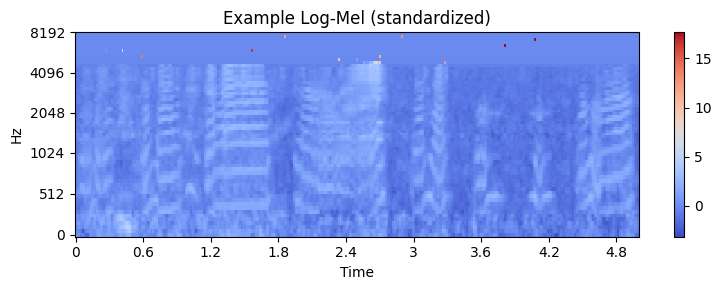

In [19]:
# Section 5: Audio Preprocessing and Log-Mel

def load_and_preprocess_waveform(path: str,
                                 sr: int = SAMPLE_RATE,
                                 duration_s: float = DURATION_SECONDS,
                                 target_db: float = TARGET_DB) -> np.ndarray:
    y, _ = librosa.load(path, sr=sr, mono=True)
    yt, _ = librosa.effects.trim(y, top_db=30)
    target_len = int(sr * duration_s)
    if len(yt) < target_len:
        yt = np.pad(yt, (0, target_len - len(yt)), mode='constant')
    else:
        yt = yt[:target_len]
    rms = np.sqrt(np.mean(yt**2) + 1e-9)
    rms_db = 20 * np.log10(rms + 1e-9)
    gain_db = target_db - rms_db
    yt = yt * (10 ** (gain_db / 20))
    peak = np.max(np.abs(yt)) + 1e-9
    if peak > 1.0:
        yt = yt / peak
    return yt.astype(np.float32)

def waveform_to_logmel(y: np.ndarray,
                        sr: int = SAMPLE_RATE,
                        n_fft: int = FFT,
                        hop_length: int = HOP,
                        n_mels: int = N_MELS) -> np.ndarray:
    S = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels, power=2.0
    )
    S_db = librosa.power_to_db(S, ref=np.max)
    mu = S_db.mean(axis=1, keepdims=True)
    std = S_db.std(axis=1, keepdims=True) + 1e-6
    S_std = (S_db - mu) / std
    return S_std.astype(np.float32)

# Visualize example
if len(df) > 0:
    ex_fp = df.sample(1, random_state=SEED).iloc[0]['filepath']
    y = load_and_preprocess_waveform(ex_fp)
    M = waveform_to_logmel(y)
    plt.figure(figsize=(8, 3))
    librosa.display.specshow(M, sr=SAMPLE_RATE, hop_length=HOP, x_axis='time', y_axis='mel')
    plt.title('Example Log-Mel (standardized)')
    plt.colorbar()
    plt.tight_layout()
    plt.show()

### 🔹 1. Load and Preprocess Waveform

```python
def load_and_preprocess_waveform(path: str, sr=SAMPLE_RATE, duration_s=DURATION_SECONDS, target_db=TARGET_DB):
```

This function prepares raw audio for feature extraction.

**Steps inside:**

1. **Load audio**:

   ```python
   y, _ = librosa.load(path, sr=sr, mono=True)
   ```

   * Loads as **mono** and resamples to `sr`.

2. **Trim silence**:

   ```python
   yt, _ = librosa.effects.trim(y, top_db=30)
   ```

   * Removes leading/trailing silence.

3. **Fix length**:

   ```python
   target_len = int(sr * duration_s)
   if len(yt) < target_len:
       yt = np.pad(yt, (0, target_len - len(yt)), mode='constant')
   else:
       yt = yt[:target_len]
   ```

   * Pads shorter audio with zeros or truncates longer ones to a **fixed duration**.

4. **Normalize loudness to target dB**:

   ```python
   rms = np.sqrt(np.mean(yt**2) + 1e-9)
   rms_db = 20 * np.log10(rms + 1e-9)
   gain_db = target_db - rms_db
   yt = yt * (10 ** (gain_db / 20))
   ```

   * Ensures all audio has roughly the **same loudness**, improving model consistency.

5. **Prevent clipping**:

   ```python
   peak = np.max(np.abs(yt)) + 1e-9
   if peak > 1.0:
       yt = yt / peak
   ```

   * Makes sure audio values stay in [-1, 1].

6. **Return float32 waveform**:

   ```python
   return yt.astype(np.float32)
   ```

---

### 🔹 2. Convert Waveform to Log-Mel Spectrogram

```python
def waveform_to_logmel(y: np.ndarray, sr=SAMPLE_RATE, n_fft=FFT, hop_length=HOP, n_mels=N_MELS):
```

**Steps inside:**

1. **Compute Mel spectrogram**:

   ```python
   S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels, power=2.0)
   ```

   * Converts audio to **Mel scale** (human auditory scale) and uses **power=2** for amplitude².

2. **Convert to dB scale**:

   ```python
   S_db = librosa.power_to_db(S, ref=np.max)
   ```

   * Logarithmic scale improves model learning (like human hearing).

3. **Standardize per frequency**:

   ```python
   mu = S_db.mean(axis=1, keepdims=True)
   std = S_db.std(axis=1, keepdims=True) + 1e-6
   S_std = (S_db - mu) / std
   ```

   * Normalizes each Mel frequency to mean=0, std=1 → helps model converge faster.

4. **Return float32 array**:

   ```python
   return S_std.astype(np.float32)
   ```

---

### 🔹 3. Visualize Example

```python
ex_fp = df.sample(1, random_state=SEED).iloc[0]['filepath']
y = load_and_preprocess_waveform(ex_fp)
M = waveform_to_logmel(y)
librosa.display.specshow(M, sr=SAMPLE_RATE, hop_length=HOP, x_axis='time', y_axis='mel')
plt.title('Example Log-Mel (standardized)')
plt.colorbar()
plt.show()
```

* Picks a **random file** from the dataset.
* Converts to **Log-Mel spectrogram**.
* Plots it with **time on X-axis** and **Mel frequencies on Y-axis**.
* The **color intensity** shows amplitude (loudness) in dB.

---

### 🧩 **Summary**

| Step            | Why                                         |
| --------------- | ------------------------------------------- |
| Load & trim     | Remove silence and ensure mono              |
| Pad/Truncate    | Fix audio length for batch processing       |
| Normalize dB    | Standardize loudness for all files          |
| Compute Log-Mel | Convert waveform to model-friendly features |
| Standardize     | Zero-mean, unit-variance improves training  |
| Visualize       | Quick sanity check of features              |

---

💡 **Tip:**
These functions are reusable for **train, validation, and test sets** — just call them inside your Dataset class.


# Section 6: Train-Test Splits

In [20]:
# Section 6: Train-Test Splits
labels = df['label'].values
filepaths = df['filepath'].values

fp_trainval, fp_test, y_trainval, y_test = train_test_split(
    filepaths, labels, test_size=TEST_SPLIT, random_state=SEED, stratify=labels
)
val_ratio = VAL_SPLIT / (1.0 - TEST_SPLIT)
fp_train, fp_val, y_train, y_val = train_test_split(
    fp_trainval, y_trainval, test_size=val_ratio, random_state=SEED, stratify=y_trainval
)
print(f"Train: {len(fp_train)}  Val: {len(fp_val)}  Test: {len(fp_test)}")

splits = {
    'train': { 'filepaths': fp_train.tolist(), 'labels': y_train.tolist() },
    'val':   { 'filepaths': fp_val.tolist(),   'labels': y_val.tolist()   },
    'test':  { 'filepaths': fp_test.tolist(),  'labels': y_test.tolist()  },
}
with open(output_dir / 'splits_torch.json', 'w') as f:
    json.dump(splits, f, indent=2)

Train: 2011  Val: 431  Test: 432


### 🔹 1. Extract Labels and Filepaths

```python
labels = df['label'].values
filepaths = df['filepath'].values
```

* Converts the DataFrame columns into **NumPy arrays** for easier handling with `train_test_split`.
* `labels` → 0 (non-cry) or 1 (cry)
* `filepaths` → paths to the audio files

---

### 🔹 2. Split Out Test Set

```python
fp_trainval, fp_test, y_trainval, y_test = train_test_split(
    filepaths, labels, test_size=TEST_SPLIT, random_state=SEED, stratify=labels
)
```

* **TEST_SPLIT** (e.g., 0.15) of data is held out as the **final test set**.
* `stratify=labels` ensures **class balance** in the split.
* Remaining data (`fp_trainval`) is used for **training + validation**.

---

### 🔹 3. Split Training & Validation

```python
val_ratio = VAL_SPLIT / (1.0 - TEST_SPLIT)
fp_train, fp_val, y_train, y_val = train_test_split(
    fp_trainval, y_trainval, test_size=val_ratio, random_state=SEED, stratify=y_trainval
)
```

* `VAL_SPLIT` is the fraction of **total data** to use as validation.
* We adjust it relative to the remaining data after removing test set.
* Again, `stratify=y_trainval` keeps class balance.

---

### 🔹 4. Print Sizes

```python
print(f"Train: {len(fp_train)}  Val: {len(fp_val)}  Test: {len(fp_test)}")
```

* Quick sanity check for dataset sizes.

---

### 🔹 5. Save Splits to JSON

```python
splits = {
    'train': { 'filepaths': fp_train.tolist(), 'labels': y_train.tolist() },
    'val':   { 'filepaths': fp_val.tolist(),   'labels': y_val.tolist()   },
    'test':  { 'filepaths': fp_test.tolist(),  'labels': y_test.tolist()  },
}
with open(output_dir / 'splits_torch.json', 'w') as f:
    json.dump(splits, f, indent=2)
```

* Stores the split **filepaths and labels** in a JSON file.
* Useful to **reproduce the same split** later or for inference.

---

### 🧩 **Summary**

| Step                   | Why                                     |
| ---------------------- | --------------------------------------- |
| Extract labels & paths | Prepare arrays for splitting            |
| Split test set         | Hold out final data for evaluation      |
| Split train & val      | Separate data for training & validation |
| Stratify               | Preserve class distribution             |
| Save to JSON           | Ensure reproducibility of splits        |

---

💡 **Tip:**
You can later use this JSON in your **Dataset class** to load data consistently for training, validation, and testing.



# Section 7: Torch Dataset and DataLoader

In [21]:
# Section 7: Torch Dataset and DataLoader

class CryDataset(Dataset):
    def __init__(self, filepaths: List[str], labels: List[int], augment: bool = False):
        self.filepaths = filepaths
        self.labels = labels
        self.augment = augment

    def __len__(self):
        return len(self.filepaths)

    def _augment(self, y: np.ndarray) -> np.ndarray:
        # Simple augmentations
        if random.random() < 0.5:
            gain_db = random.uniform(-6, 6)
            y = y * (10 ** (gain_db / 20))
        if random.random() < 0.5:
            max_shift = int(0.2 * SAMPLE_RATE)
            shift = random.randint(-max_shift, max_shift)
            y = np.roll(y, shift)
        if random.random() < 0.5:
            noise_level = random.uniform(0.001, 0.01)
            y = y + np.random.randn(*y.shape).astype(np.float32) * noise_level
        y = np.clip(y, -1.0, 1.0)
        return y

    def __getitem__(self, idx):
        fp = self.filepaths[idx]
        label = self.labels[idx]
        y = load_and_preprocess_waveform(fp)
        if self.augment:
            y = self._augment(y)
        M = waveform_to_logmel(y)
        # To tensor: (1, n_mels, time)
        M = torch.tensor(M, dtype=torch.float32)
        M = M.unsqueeze(0)
        return M, torch.tensor(label, dtype=torch.float32)

train_ds = CryDataset(fp_train.tolist(), y_train.tolist(), augment=True)
val_ds = CryDataset(fp_val.tolist(), y_val.tolist(), augment=False)
test_ds_torch = CryDataset(fp_test.tolist(), y_test.tolist(), augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds_torch, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

xb, yb = next(iter(train_loader))
print('Batch shapes:', xb.shape, yb.shape)  # [B,1,N_MELS,T], [B]

Batch shapes: torch.Size([32, 1, 64, 313]) torch.Size([32])


### 🔹 1. Dataset Class

```python
class CryDataset(Dataset):
```

* Inherits from `torch.utils.data.Dataset`.
* Handles **loading, preprocessing, augmentation, and conversion to tensors**.

---

#### 🔹 2. Initialization

```python
def __init__(self, filepaths: List[str], labels: List[int], augment: bool = False):
    self.filepaths = filepaths
    self.labels = labels
    self.augment = augment
```

* Stores file paths and labels.
* `augment=True` enables data augmentation (used for training only).

---

#### 🔹 3. Length

```python
def __len__(self):
    return len(self.filepaths)
```

* Returns the total number of samples.

---

#### 🔹 4. Augmentation Function

```python
def _augment(self, y: np.ndarray) -> np.ndarray:
```

Applies **random audio augmentations**:

1. **Random gain (volume change)**

   ```python
   gain_db = random.uniform(-6, 6)
   y = y * (10 ** (gain_db / 20))
   ```

2. **Random time shift**

   ```python
   shift = random.randint(-max_shift, max_shift)
   y = np.roll(y, shift)
   ```

3. **Add Gaussian noise**

   ```python
   noise_level = random.uniform(0.001, 0.01)
   y = y + np.random.randn(*y.shape).astype(np.float32) * noise_level
   ```

4. **Clip waveform** to [-1, 1] to avoid overflow:

   ```python
   y = np.clip(y, -1.0, 1.0)
   ```

---

#### 🔹 5. Get Item

```python
def __getitem__(self, idx):
    fp = self.filepaths[idx]
    label = self.labels[idx]
    y = load_and_preprocess_waveform(fp)
    if self.augment:
        y = self._augment(y)
    M = waveform_to_logmel(y)
    M = torch.tensor(M, dtype=torch.float32).unsqueeze(0)  # shape: [1, N_MELS, T]
    return M, torch.tensor(label, dtype=torch.float32)
```

* Loads audio, applies preprocessing.
* Applies augmentation if enabled.
* Converts waveform → **Log-Mel spectrogram**.
* Converts spectrogram → PyTorch tensor with shape `[1, N_MELS, T]` (1 channel for CNN).
* Returns `(features, label)`.

---

### 🔹 6. Create Dataset Instances

```python
train_ds = CryDataset(fp_train.tolist(), y_train.tolist(), augment=True)
val_ds = CryDataset(fp_val.tolist(), y_val.tolist(), augment=False)
test_ds_torch = CryDataset(fp_test.tolist(), y_test.tolist(), augment=False)
```

* Training set uses augmentation, validation/test do **not**.

---

### 🔹 7. Wrap in DataLoaders

```python
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds_torch, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
```

* `batch_size=BATCH_SIZE` → number of samples per batch.
* `shuffle=True` for training to improve learning.
* `num_workers=0` → single-threaded data loading (increase for faster loading on CPUs).

---

### 🔹 8. Check Batch Shapes

```python
xb, yb = next(iter(train_loader))
print('Batch shapes:', xb.shape, yb.shape)  # [B,1,N_MELS,T], [B]
```

* Confirms tensors:

  * `xb.shape` → `[batch_size, 1, n_mels, time]`
  * `yb.shape` → `[batch_size]`

This is exactly what a CNN expects for training.

---

💡 **Summary**

| Step         | Purpose                                            |
| ------------ | -------------------------------------------------- |
| `CryDataset` | Load audio, preprocess, augment, convert to tensor |
| `_augment`   | Random gain, shift, noise for training robustness  |
| DataLoaders  | Batch data for efficient GPU training              |
| Shapes       | `[B,1,N_MELS,T]` for CNN input                     |



# Section 8: Model Definition

In [22]:
# Section 8: Model Definition

class CNNBabyCry(nn.Module):
    def __init__(self):
        super().__init__()
        # Input (B,1,N_MELS,T)
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.dropout = nn.Dropout(0.3)
        self.pool = nn.MaxPool2d(2)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(128, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.dropout(x)
        x = self.gap(x).squeeze(-1).squeeze(-1)  # (B, C)
        x = self.fc(x)
        return x.view(-1)

model = CNNBabyCry().to(DEVICE)
print(model)

CNNBabyCry(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (gap): AdaptiveAvgPool2d(output_size=1)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


### 🔹 1. Model Class

```python
class CNNBabyCry(nn.Module):
```

* Inherits from PyTorch’s `nn.Module`.
* Designed to take **Log-Mel spectrograms** of shape `[B, 1, N_MELS, T]` as input.

---

### 🔹 2. Convolutional Layers

```python
self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
self.bn1 = nn.BatchNorm2d(32)
self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
self.bn2 = nn.BatchNorm2d(64)
self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
self.bn3 = nn.BatchNorm2d(128)
```

* **conv1 → conv3** extract hierarchical features from the spectrogram.
* **BatchNorm2d** normalizes features to improve training stability.
* **Padding=1** keeps spatial dimensions the same after convolution.

---

### 🔹 3. Pooling and Dropout

```python
self.pool = nn.MaxPool2d(2)
self.dropout = nn.Dropout(0.3)
```

* **MaxPool2d(2)** → reduces the feature map size by 2 (downsampling).
* **Dropout(0.3)** → randomly zeroes 30% of neurons to reduce overfitting.

---

### 🔹 4. Global Average Pooling

```python
self.gap = nn.AdaptiveAvgPool2d(1)
```

* Converts variable-sized feature maps to **1x1 per channel**.
* Output shape: `(B, C, 1, 1)` → squeeze to `(B, C)` for fully connected layer.

---

### 🔹 5. Fully Connected Layer

```python
self.fc = nn.Linear(128, 1)
```

* Takes 128 features from the last conv layer.
* Outputs **1 value per sample** (logit for BCEWithLogitsLoss).

---

### 🔹 6. Forward Pass

```python
def forward(self, x):
    x = self.pool(F.relu(self.bn1(self.conv1(x))))
    x = self.pool(F.relu(self.bn2(self.conv2(x))))
    x = self.pool(F.relu(self.bn3(self.conv3(x))))
    x = self.dropout(x)
    x = self.gap(x).squeeze(-1).squeeze(-1)  # (B, C)
    x = self.fc(x)
    return x.view(-1)
```

Step by step:

1. **Conv → BN → ReLU → Pool** three times.
2. Apply **Dropout**.
3. **Global average pooling** → `(B, 128)`
4. Fully connected → output logit `(B,)`.

* Output is a **1D tensor of logits** for each sample.

---

### 🔹 7. Instantiate Model

```python
model = CNNBabyCry().to(DEVICE)
print(model)
```

* Moves the model to **GPU or CPU** depending on availability.
* Printing shows the **layer structure and parameters**.

---

### 🧩 **Summary**

| Layer              | Purpose                                         |
| ------------------ | ----------------------------------------------- |
| Conv2d + BN + ReLU | Feature extraction from spectrogram             |
| MaxPool2d          | Downsampling / reduce dimensions                |
| Dropout            | Prevent overfitting                             |
| AdaptiveAvgPool2d  | Global pooling to flatten variable-length input |
| Linear             | Output logit for binary classification          |

---

💡 **Tip:**

* Input shape `[B, 1, N_MELS, T]` is compatible with CNN.
* Output logit is fed to `BCEWithLogitsLoss` during training.



# Section 9: Optimizer, Scheduler, Training Utils

In [23]:
# Section 9: Optimizer, Scheduler, Training Utils

pos_weight = None
# Optional: compute pos_weight for BCEWithLogitsLoss if class imbalance severe
num_pos = int((np.array(y_train) == 1).sum())
num_neg = int((np.array(y_train) == 0).sum())
if num_pos > 0 and num_neg > 0:
    pos_weight = torch.tensor([num_neg / max(num_pos, 1)], device=DEVICE, dtype=torch.float32)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight) if pos_weight is not None else nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
# Remove 'verbose' for compatibility with older PyTorch versions
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

best_val_auc = -np.inf
ckpt_path = output_dir / 'cnn_baby_cry_torch.pt'

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
    return running_loss / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_probs = []
    all_targets = []
    running_loss = 0.0
    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        logits = model(xb)
        loss = criterion(logits, yb)
        probs = torch.sigmoid(logits)
        all_probs.append(probs.detach().cpu().numpy())
        all_targets.append(yb.detach().cpu().numpy())
        running_loss += loss.item() * xb.size(0)
    all_probs = np.concatenate(all_probs)
    all_targets = np.concatenate(all_targets).astype(int)
    auc = roc_auc_score(all_targets, all_probs) if len(np.unique(all_targets)) > 1 else 0.0
    return running_loss / len(loader.dataset), auc, all_probs, all_targets

### 🧩 **1. Handling Class Imbalance**

```python
pos_weight = None
num_pos = int((np.array(y_train) == 1).sum())
num_neg = int((np.array(y_train) == 0).sum())
if num_pos > 0 and num_neg > 0:
    pos_weight = torch.tensor([num_neg / max(num_pos, 1)], device=DEVICE, dtype=torch.float32)
```

* Here, you’re checking if your dataset has **unequal numbers of positive and negative samples** (for example, more “non-cry” than “cry” sounds).
* If there’s imbalance, you calculate a **weight (`pos_weight`)** to make the model pay more attention to the minority class (the one with fewer samples).
* The weight is `num_neg / num_pos`, meaning the rarer class will have a higher weight.

---

### ⚖️ **2. Loss Function**

```python
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight) if pos_weight is not None else nn.BCEWithLogitsLoss()
```

* The **loss function** tells the model how wrong it is during training.
* `BCEWithLogitsLoss` is used for **binary classification** (like “cry” vs “non-cry”).
* If `pos_weight` exists, it helps handle imbalance by giving more importance to the minority class.

---

### ⚙️ **3. Optimizer**

```python
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
```

* The **optimizer** updates the model’s weights to reduce the loss.
* `Adam` is a popular optimizer that adapts learning rates automatically for each parameter.

---

### ⏬ **4. Learning Rate Scheduler**

```python
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
```

* The **scheduler** helps adjust the learning rate if the model stops improving.
* If the validation loss doesn’t improve for 3 epochs, the learning rate is cut in half (`factor=0.5`).
* This helps fine-tune training and avoid getting stuck.

---

### 🏆 **5. Tracking Best Model**

```python
best_val_auc = -np.inf
ckpt_path = output_dir / 'cnn_baby_cry_torch.pt'
```

* `best_val_auc` stores the **best validation AUC score** seen so far.
* `ckpt_path` is the file path where the **best model checkpoint** will be saved.

---

### 🔁 **6. Training One Epoch**

```python
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
    return running_loss / len(loader.dataset)
```

Step-by-step:

1. `model.train()` → sets model in **training mode**.
2. Loop through the **data loader** batch by batch.
3. Move input (`xb`) and label (`yb`) to GPU or CPU (`DEVICE`).
4. Zero the gradients before backprop.
5. Get predictions (`logits`) from the model.
6. Compute loss (difference between prediction and truth).
7. Backpropagate (`loss.backward()`).
8. Update weights (`optimizer.step()`).
9. Track total loss and return the **average loss** for the epoch.

---

### 🔍 **7. Evaluation Function**

```python
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_probs = []
    all_targets = []
    running_loss = 0.0
    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        logits = model(xb)
        loss = criterion(logits, yb)
        probs = torch.sigmoid(logits)
        all_probs.append(probs.detach().cpu().numpy())
        all_targets.append(yb.detach().cpu().numpy())
        running_loss += loss.item() * xb.size(0)
    all_probs = np.concatenate(all_probs)
    all_targets = np.concatenate(all_targets).astype(int)
    auc = roc_auc_score(all_targets, all_probs) if len(np.unique(all_targets)) > 1 else 0.0
    return running_loss / len(loader.dataset), auc, all_probs, all_targets
```

Step-by-step:

1. `@torch.no_grad()` → disables gradient calculation (saves memory).
2. `model.eval()` → sets model to **evaluation mode** (turns off dropout, etc.).
3. Loop through data, move to `DEVICE`, and get predictions.
4. Compute loss for monitoring.
5. Apply `sigmoid` to get probabilities (since output logits aren’t between 0–1).
6. Collect predictions (`all_probs`) and true labels (`all_targets`).
7. Compute **AUC (Area Under Curve)** — a measure of classification performance (higher = better).
8. Return the average loss, AUC score, predicted probabilities, and actual labels.

---

### 🧠 **In Short**

* **`train_one_epoch()`** → trains the model for one full pass through the data.
* **`evaluate()`** → checks how well the model performs on validation/test data.
* **`criterion`**, **`optimizer`**, and **`scheduler`** control how the model learns.
* **`pos_weight`** helps deal with unbalanced datasets.



# Section 10: Training Loop with Early Stopping


Epoch 1/200
------------------------------


Epoch 001/200 | train_loss=0.4153 | val_loss=0.3885 | val_auc=0.9480
  ✅ Saved checkpoint -> /content/CSE299/models/cnn_baby_cry_torch.pt

Epoch 2/200
------------------------------


Epoch 002/200 | train_loss=0.3454 | val_loss=0.3308 | val_auc=0.9426

Epoch 3/200
------------------------------


Epoch 003/200 | train_loss=0.3101 | val_loss=0.5732 | val_auc=0.9599
  ✅ Saved checkpoint -> /content/CSE299/models/cnn_baby_cry_torch.pt

Epoch 4/200
------------------------------


Epoch 004/200 | train_loss=0.2888 | val_loss=0.3269 | val_auc=0.9652
  ✅ Saved checkpoint -> /content/CSE299/models/cnn_baby_cry_torch.pt

Epoch 5/200
------------------------------


...

Epoch 023/200 | train_loss=0.2217 | val_loss=0.1895 | val_auc=0.9772

Epoch 24/200
------------------------------


Epoch 024/200 | train_loss=0.2166 | val_loss=0.2017 | val_auc=0.9742

Epoch 25/200
------------------------------


Epoch 025/200 | train_loss=0.2378 | val_loss=0.1996 | val_auc=0.9742

Epoch 26/200
------------------------------


Epoch 026/200 | train_loss=0.2266 | val_loss=0.2007 | val_auc=0.9776

Epoch 27/200
------------------------------


  LR reduced: 0.001 -> 0.0005
Epoch 027/200 | train_loss=0.2135 | val_loss=0.2220 | val_auc=0.9751
⏹️ Early stopping triggered.


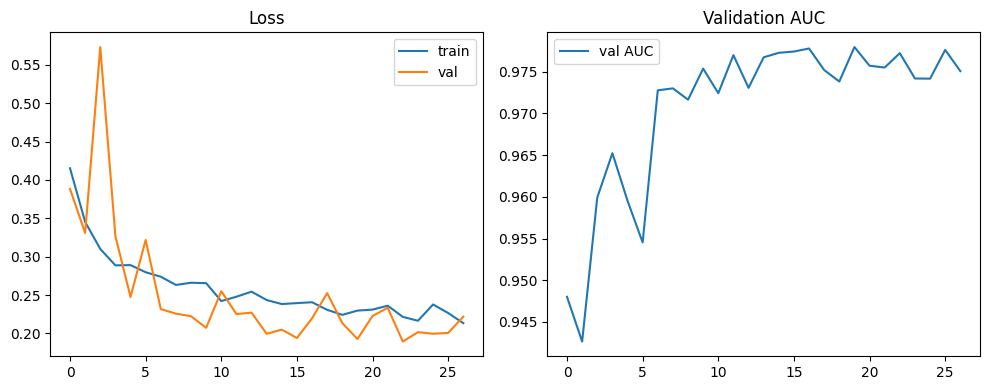

In [24]:
# Section 10: Training Loop with Early Stopping

patience = 7
no_improve = 0
history = {'train_loss': [], 'val_loss': [], 'val_auc': []}

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")
    print("-" * 30)

    # Wrap the training loader with tqdm for progress display
    train_loader_tqdm = tqdm(train_loader, desc=f"Training [{epoch}/{EPOCHS}]", leave=False)
    total_train_loss = 0.0

    # ---- Training ----
    model.train()
    for batch in train_loader_tqdm:
        optimizer.zero_grad()
        inputs, targets = batch
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        train_loader_tqdm.set_postfix(loss=loss.item())

    train_loss = total_train_loss / len(train_loader)

    # ---- Validation ----
    val_loss, val_auc, _, _ = evaluate(model, val_loader)

    # ---- Scheduler ----
    prev_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)
    new_lr = optimizer.param_groups[0]['lr']
    if new_lr < prev_lr:
        print(f"  LR reduced: {prev_lr:.6g} -> {new_lr:.6g}")

    # ---- Record history ----
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_auc)

    # ---- Display summary ----
    print(f"Epoch {epoch:03d}/{EPOCHS} | "
          f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_auc={val_auc:.4f}")

    # ---- Early Stopping ----
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        no_improve = 0
        torch.save({
            'model_state': model.state_dict(),
            'config': {
                'SAMPLE_RATE': SAMPLE_RATE,
                'DURATION_SECONDS': DURATION_SECONDS,
                'N_MELS': N_MELS,
                'FFT': FFT,
                'HOP': HOP,
                'TARGET_DB': TARGET_DB,
            }
        }, ckpt_path)
        print(f'  ✅ Saved checkpoint -> {ckpt_path}')
    else:
        no_improve += 1
        if no_improve >= patience:
            print('⏹️ Early stopping triggered.')
            break

# ---- Plot training curves ----
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history['train_loss'], label='train')
plt.plot(history['val_loss'], label='val')
plt.title('Loss'); plt.legend()
plt.subplot(1,2,2)
plt.plot(history['val_auc'], label='val AUC')
plt.title('Validation AUC'); plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / 'training_curves_torch.png', dpi=120)
plt.show()


## 🧠 What This Section Does:

This code trains your CNN model for baby cry detection over several epochs while:

* tracking losses and performance (AUC)
* adjusting learning rate when needed
* saving the best model
* stopping automatically if no progress is made.

---

## 🪜 Step-by-Step Breakdown

### 🧩 1. Setup for Early Stopping and History

```python
patience = 7
no_improve = 0
history = {'train_loss': [], 'val_loss': [], 'val_auc': []}
```

* **`patience = 7`** → if the model doesn’t improve in validation AUC for 7 consecutive epochs, training will stop early.
* **`no_improve`** → counts how many epochs have gone by without improvement.
* **`history`** → stores the losses and AUCs for plotting later.

---

### 🔁 2. Loop Over Epochs

```python
for epoch in range(1, EPOCHS + 1):
```

* Each **epoch** means one full pass through all your training data.
* The loop runs until the total number of epochs, unless early stopping triggers.

---

### 📊 3. Training Phase

```python
train_loader_tqdm = tqdm(train_loader, desc=f"Training [{epoch}/{EPOCHS}]", leave=False)
```

* Wraps the data loader with **tqdm**, which shows a progress bar in the terminal.

---

Inside the training loop:

```python
model.train()
for batch in train_loader_tqdm:
    optimizer.zero_grad()
    inputs, targets = batch
    inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
    outputs = model(inputs)
    loss = criterion(outputs, targets)
    loss.backward()
    optimizer.step()
```

Step-by-step:

1. `model.train()` → enables training mode (activates dropout, batchnorm, etc.).
2. Loops through each mini-batch from `train_loader`.
3. **Zero gradients** before each batch (`optimizer.zero_grad()`).
4. Moves data to GPU/CPU (`inputs.to(DEVICE)`).
5. Gets predictions (`outputs = model(inputs)`).
6. Calculates **loss** (how far prediction is from actual label).
7. Performs **backpropagation** (`loss.backward()`).
8. Updates model weights (`optimizer.step()`).

---

### 📉 4. Track Training Loss

```python
total_train_loss += loss.item()
train_loader_tqdm.set_postfix(loss=loss.item())
train_loss = total_train_loss / len(train_loader)
```

* Adds up the batch losses to compute the average loss for the whole epoch.
* Shows the loss live on the progress bar.

---

### 🧪 5. Validation Phase

```python
val_loss, val_auc, _, _ = evaluate(model, val_loader)
```

* Calls your earlier `evaluate()` function to:

  * compute **validation loss**
  * compute **validation AUC (performance metric)**
* AUC is a good measure for binary classification (higher = better).

---

### ⚙️ 6. Learning Rate Scheduler

```python
prev_lr = optimizer.param_groups[0]['lr']
scheduler.step(val_loss)
new_lr = optimizer.param_groups[0]['lr']
if new_lr < prev_lr:
    print(f"  LR reduced: {prev_lr:.6g} -> {new_lr:.6g}")
```

* The **scheduler** checks if validation loss improved.
* If not, it automatically **reduces the learning rate** (helps model fine-tune and escape plateaus).

---

### 📝 7. Save Metrics

```python
history['train_loss'].append(train_loss)
history['val_loss'].append(val_loss)
history['val_auc'].append(val_auc)
```

* Stores training and validation results for later visualization.

---

### 🏁 8. Show Summary

```python
print(f"Epoch {epoch:03d}/{EPOCHS} | "
      f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_auc={val_auc:.4f}")
```

* Prints a summary of the current epoch’s performance.

---

### 💾 9. Early Stopping and Checkpoint Saving

```python
if val_auc > best_val_auc:
    best_val_auc = val_auc
    no_improve = 0
    torch.save({...}, ckpt_path)
    print(f'  ✅ Saved checkpoint -> {ckpt_path}')
else:
    no_improve += 1
    if no_improve >= patience:
        print('⏹️ Early stopping triggered.')
        break
```

Explanation:

* If **validation AUC improves**, the model:

  * updates `best_val_auc`
  * resets `no_improve`
  * **saves the model** (so you keep the best one!)
* If AUC **doesn’t improve**, `no_improve` increases.
* When `no_improve` ≥ `patience`, training stops early — avoids wasting time on a model that’s not improving.

---

### 📈 10. Plot the Results

```python
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history['train_loss'], label='train')
plt.plot(history['val_loss'], label='val')
plt.title('Loss'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history['val_auc'], label='val AUC')
plt.title('Validation AUC'); plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / 'training_curves_torch.png', dpi=120)
plt.show()
```

* Creates two plots:

  1. **Train vs Validation Loss** → shows how loss decreases over time.
  2. **Validation AUC** → shows performance improvements.
* Finally, saves the plot image in your `fig_dir`.

---

## 🧩 Summary

| Part                  | Purpose                                      |
| --------------------- | -------------------------------------------- |
| **Training loop**     | Repeats training and validation each epoch   |
| **Early stopping**    | Stops if no improvement after several epochs |
| **Scheduler**         | Reduces learning rate when stuck             |
| **Checkpoint saving** | Keeps best model based on AUC                |
| **History tracking**  | Stores results for plotting later            |



Test ROC AUC: 0.9725199348366629
Accuracy: 0.8796296296296297
              precision    recall  f1-score   support

     non-cry       0.90      0.85      0.88       214
         cry       0.86      0.91      0.88       218

    accuracy                           0.88       432
   macro avg       0.88      0.88      0.88       432
weighted avg       0.88      0.88      0.88       432



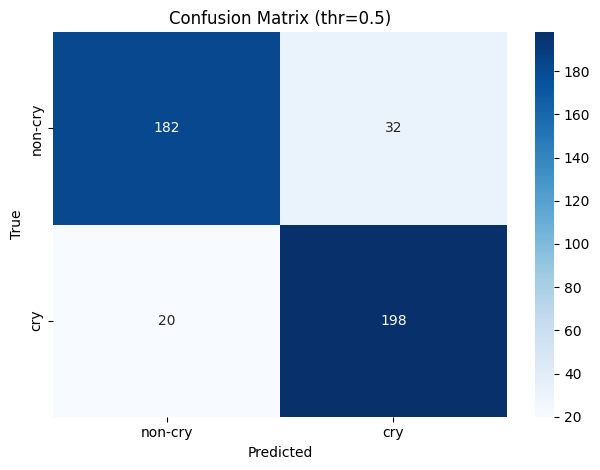

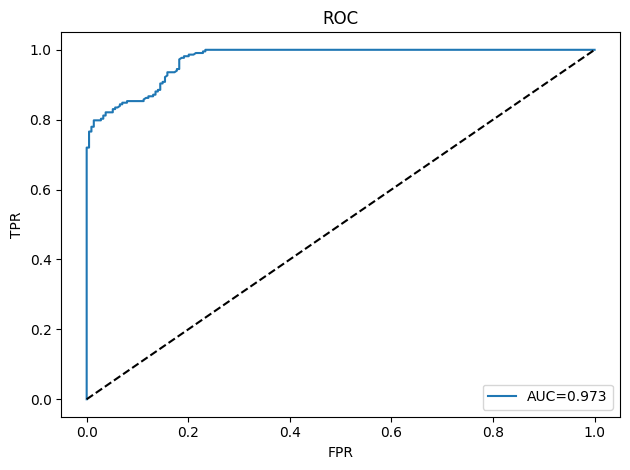

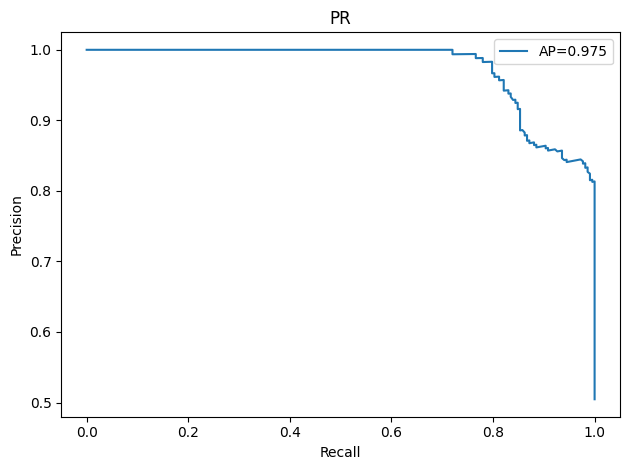

In [25]:
# Section 11: Evaluation on Test Set

# Load best checkpoint
ckpt = torch.load(ckpt_path, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
model.eval()

with torch.no_grad():
    test_loss, test_auc, test_probs, test_targets = evaluate(model, test_loader)

print('Test ROC AUC:', test_auc)

# Default threshold 0.5
preds = (test_probs >= 0.5).astype(int)
print('Accuracy:', (preds == test_targets).mean())
print(classification_report(test_targets, preds, target_names=['non-cry','cry']))

cm = confusion_matrix(test_targets, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['non-cry','cry'], yticklabels=['non-cry','cry'])
plt.title('Confusion Matrix (thr=0.5)')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout()
plt.savefig(fig_dir / 'confusion_matrix_torch.png', dpi=120)
plt.show()

# ROC/PR curves
fpr, tpr, _ = roc_curve(test_targets, test_probs)
plt.figure(); plt.plot(fpr, tpr, label=f'AUC={roc_auc_score(test_targets, test_probs):.3f}')
plt.plot([0,1],[0,1],'k--'); plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC'); plt.legend(); plt.tight_layout();
plt.savefig(fig_dir / 'roc_curve_torch.png', dpi=120)
plt.show()

prec, rec, _ = precision_recall_curve(test_targets, test_probs)
plt.figure(); plt.plot(rec, prec, label=f'AP={average_precision_score(test_targets, test_probs):.3f}')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('PR'); plt.legend(); plt.tight_layout();
plt.savefig(fig_dir / 'pr_curve_torch.png', dpi=120)
plt.show()

## 🎯 **Section Goal:**

Use the **best saved model** to:

1. Evaluate performance on the test set
2. Measure accuracy, ROC AUC, precision, recall, etc.
3. Visualize confusion matrix, ROC curve, and PR curve.

---

## 🧩 1. Load the Best Model

```python
ckpt = torch.load(ckpt_path, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
model.eval()
```

* Loads the **saved model checkpoint** (`ckpt_path`) from training.
* `map_location=DEVICE` ensures it loads on the right device (GPU or CPU).
* `model.load_state_dict(...)` restores the trained weights.
* `model.eval()` puts the model into **evaluation mode** (turns off dropout, etc.).

✅ Now your model is ready for testing — it’s the **best version** found during training.

---

## 🧪 2. Evaluate on Test Data

```python
with torch.no_grad():
    test_loss, test_auc, test_probs, test_targets = evaluate(model, test_loader)
```

* Runs the same `evaluate()` function from earlier, but on **test data**.
* `torch.no_grad()` disables gradient tracking → faster and saves memory.
* Returns:

  * `test_loss`: average loss on test data
  * `test_auc`: ROC-AUC score (overall classification performance)
  * `test_probs`: predicted probabilities (between 0–1)
  * `test_targets`: actual labels (0 or 1)

---

## 📊 3. Print Test Results

```python
print('Test ROC AUC:', test_auc)
```

* Shows the **ROC AUC score** — a higher value means better classification.

  * 1.0 = perfect
  * 0.5 = random guessing

---

## ✅ 4. Convert Probabilities to Class Predictions

```python
preds = (test_probs >= 0.5).astype(int)
```

* Turns probabilities into binary predictions:

  * ≥ 0.5 → predict “cry” (1)
  * < 0.5 → predict “non-cry” (0)

---

## 📈 5. Calculate Accuracy and Detailed Report

```python
print('Accuracy:', (preds == test_targets).mean())
print(classification_report(test_targets, preds, target_names=['non-cry','cry']))
```

* **Accuracy:** fraction of correct predictions.
* **Classification report:** shows precision, recall, F1-score for each class.

  * **Precision:** how many predicted “cry” are actually cry.
  * **Recall:** how many actual “cry” sounds were correctly detected.
  * **F1-score:** balance between precision & recall.

---

## 🧾 6. Confusion Matrix

```python
cm = confusion_matrix(test_targets, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['non-cry','cry'], yticklabels=['non-cry','cry'])
plt.title('Confusion Matrix (thr=0.5)')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout()
plt.savefig(fig_dir / 'confusion_matrix_torch.png', dpi=120)
plt.show()
```

* Creates a **confusion matrix** to visualize prediction results:

  |              | Predicted non-cry | Predicted cry  |
  | ------------ | ----------------- | -------------- |
  | True non-cry | True Negative     | False Positive |
  | True cry     | False Negative    | True Positive  |
* `sns.heatmap()` shows this nicely as a blue grid.
* Saves the figure as an image.

---

## 📈 7. ROC Curve (Receiver Operating Characteristic)

```python
fpr, tpr, _ = roc_curve(test_targets, test_probs)
plt.figure(); plt.plot(fpr, tpr, label=f'AUC={roc_auc_score(test_targets, test_probs):.3f}')
plt.plot([0,1],[0,1],'k--'); plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC'); plt.legend(); plt.tight_layout();
plt.savefig(fig_dir / 'roc_curve_torch.png', dpi=120)
plt.show()
```

* Plots the **ROC curve**, showing the trade-off between:

  * **FPR (False Positive Rate)**
  * **TPR (True Positive Rate)**
* The **AUC** (area under curve) shows how well the model separates the two classes.

  * Closer to 1.0 = better performance.
* The diagonal line (`k--`) shows random guessing.

---

## 📊 8. Precision–Recall Curve

```python
prec, rec, _ = precision_recall_curve(test_targets, test_probs)
plt.figure(); plt.plot(rec, prec, label=f'AP={average_precision_score(test_targets, test_probs):.3f}')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('PR'); plt.legend(); plt.tight_layout();
plt.savefig(fig_dir / 'pr_curve_torch.png', dpi=120)
plt.show()
```

* Plots **Precision vs Recall** across thresholds.
* **AP (Average Precision)** is the area under this curve — another performance metric (especially useful for imbalanced data).
* Saves the figure to your results folder.

---

## 🧩 **Summary (Plain Words)**

| Step              | Purpose                                       |
| ----------------- | --------------------------------------------- |
| Load model        | Restore the best trained version              |
| Evaluate          | Compute test loss and AUC                     |
| Predictions       | Convert probabilities into 0/1 outputs        |
| Accuracy & Report | Measure how well model classifies cry/non-cry |
| Confusion Matrix  | See where model makes mistakes                |
| ROC Curve         | Visualize classification quality              |
| PR Curve          | Useful for imbalanced datasets                |



# Section 12: Threshold Tuning and Save Assets

Best threshold: 0.280  F1=0.905


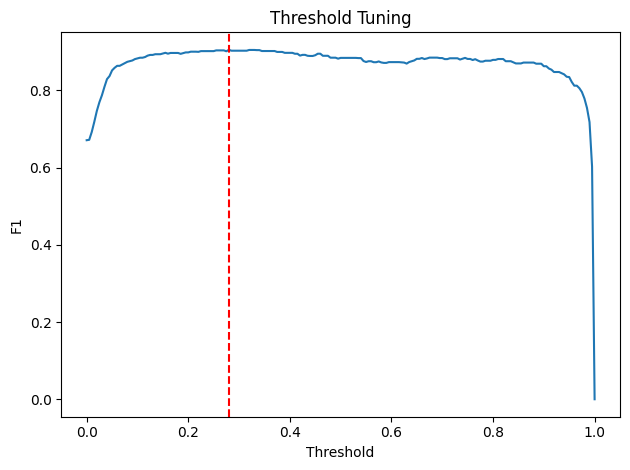

Saved threshold and labels map to /content/CSE299/models


In [26]:
# Section 12: Threshold Tuning and Save Assets

thresholds = np.linspace(0, 1, 201)
best = max(((t, f1_score(test_targets, (test_probs >= t).astype(int))) for t in thresholds), key=lambda x: x[1])
best_t, best_f1 = best
print(f'Best threshold: {best_t:.3f}  F1={best_f1:.3f}')

plt.figure(); plt.plot(thresholds, [f1_score(test_targets, (test_probs >= t).astype(int)) for t in thresholds])
plt.axvline(best_t, color='r', linestyle='--'); plt.xlabel('Threshold'); plt.ylabel('F1'); plt.title('Threshold Tuning'); plt.tight_layout();
plt.savefig(fig_dir / 'threshold_tuning_torch.png', dpi=120)
plt.show()

# Save threshold and label map
with open(output_dir / 'threshold_torch.json', 'w') as f:
    json.dump({'threshold': float(best_t)}, f, indent=2)
with open(output_dir / 'labels.json', 'w') as f:
    json.dump({'0': 'non-cry', '1': 'cry'}, f, indent=2)

print('Saved threshold and labels map to', output_dir)

## 🎯 **Goal of This Section**

After testing, you find the **best cutoff threshold** (not always 0.5) that gives the **highest F1-score**, then save it along with label info for future use (like during deployment).

---

## 🧩 1. Generate Thresholds to Test

```python
thresholds = np.linspace(0, 1, 201)
```

* Creates **201 equally spaced thresholds** between 0 and 1.
* Example: `[0.0, 0.005, 0.01, ..., 0.995, 1.0]`
* These thresholds will be used to test which cutoff gives the best performance.

---

## 🧮 2. Compute F1-Score for Each Threshold

```python
best = max(((t, f1_score(test_targets, (test_probs >= t).astype(int))) for t in thresholds), key=lambda x: x[1])
best_t, best_f1 = best
print(f'Best threshold: {best_t:.3f}  F1={best_f1:.3f}')
```

Let’s break it down:

* `(test_probs >= t).astype(int)` → turns probabilities into predictions using a given threshold `t`.
* `f1_score(...)` → computes the F1-score for that threshold.
* The generator `(t, f1_score(...)) for t in thresholds` creates pairs of `(threshold, F1)`.
* `max(..., key=lambda x: x[1])` → picks the pair with the **highest F1-score**.
* `best_t` = best threshold
* `best_f1` = best F1-score

✅ Prints something like:

```
Best threshold: 0.43  F1=0.89
```

---

## 📊 3. Plot F1 vs Threshold

```python
plt.figure()
plt.plot(thresholds, [f1_score(test_targets, (test_probs >= t).astype(int)) for t in thresholds])
plt.axvline(best_t, color='r', linestyle='--')
plt.xlabel('Threshold'); plt.ylabel('F1'); plt.title('Threshold Tuning')
plt.tight_layout()
plt.savefig(fig_dir / 'threshold_tuning_torch.png', dpi=120)
plt.show()
```

* This creates a **curve** showing how F1-score changes as the threshold moves from 0 → 1.
* The **red dashed line** (`axvline`) marks the best threshold.
* The plot helps visualize where your model performs best.

🖼️ Example interpretation:

* If F1 peaks at ~0.43, then using 0.43 instead of 0.5 gives a better balance between **precision** and **recall**.

---

## 💾 4. Save Threshold and Label Mapping

```python
with open(output_dir / 'threshold_torch.json', 'w') as f:
    json.dump({'threshold': float(best_t)}, f, indent=2)

with open(output_dir / 'labels.json', 'w') as f:
    json.dump({'0': 'non-cry', '1': 'cry'}, f, indent=2)
```

* Saves the best threshold value in a **JSON file** (`threshold_torch.json`).
* Also saves the **class label mapping** in `labels.json` so future scripts know what 0 and 1 mean.

✅ These files are useful during **deployment/inference**, ensuring your model uses the same settings as during evaluation.

---

## 🧾 5. Confirmation Message

```python
print('Saved threshold and labels map to', output_dir)
```

* Just prints a confirmation message showing where the JSON files were stored.

---

## 🧩 **In Summary**

| Step                    | What It Does                                                           |
| ----------------------- | ---------------------------------------------------------------------- |
| 1️⃣ Generate thresholds | Creates values between 0–1 to test                                     |
| 2️⃣ Find best F1-score  | Chooses the threshold giving highest F1                                |
| 3️⃣ Plot curve          | Visualizes F1 vs threshold                                             |
| 4️⃣ Save JSON files     | Stores best threshold and label info                                   |
| ✅ Result                | You know the *optimal threshold* for your model and can reuse it later |

---

### 💡 Why This Matters:

* Default 0.5 threshold doesn’t always give the best results — especially in **imbalanced datasets** (like “cry” sounds being rare).
* This section ensures your final deployed model **makes decisions optimally** based on data-driven tuning.

